## Notebook 3: NODEs (using Adjoints)

This notebook illustrates the training and prediction of a very simple Neural Ordinary Differential Equation (NODEs) model.  The data is fictitiously generated from solving

$\frac{du}{dt}=-u^2$

with initial condition $u(0)=1.0$. Training data is generated for $t\in[0,2]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,5]$.  

The NODEs model look like

$\frac{du}{dt}=NN(u;\vec{p})$


The Neural Network has one input, $u$ and one output $du(t)/dt$.  In this Notebook, the parameters of the Neural Network, $NN(u;\vec{p})$, will be trained by using a time stepping method to predict $u_i$ and then using the discrete adjoint method to find the coefficients of the the Neural Network such that it best fits the data.  In this notebook, we will use the standard SciML package in Julia to train the Neural Network. In the next Notebook, we will go into more details of this training method.   


In [10]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Training parameters

In [11]:
max_iter_NODEs=10_000
learning_rate=0.01

0.01

Parameters of the training and validation data set.

In [12]:
rng = Xoshiro(0)
u0 = Float32[1.0]
datasize = 150
tspan = (0.0f0, 2.0f0)
#tspan = (0.0f0, 1.0f0)

tsteps = range(tspan[1], tspan[2]; length = datasize)

tspan2 = (0.0f0, 5.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 200)

noise=0.002
#noise=0.01

0.002

Define governing equation

$\frac{du}{dt}=-u^2$


In [13]:
function trueODEfunc(du, u, p, t)
    du[1]=-u[1]*u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [14]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

1×150 Matrix{Float64}:
 1.00122  0.986255  0.973336  0.963556  …  0.339356  0.333394  0.334099

Generating Validation data

In [15]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

1×200 Matrix{Float32}:
 1.0  0.97549  0.952153  0.929907  0.908676  …  0.168083  0.167376  0.166675

Plot and have a look at the training and validation data

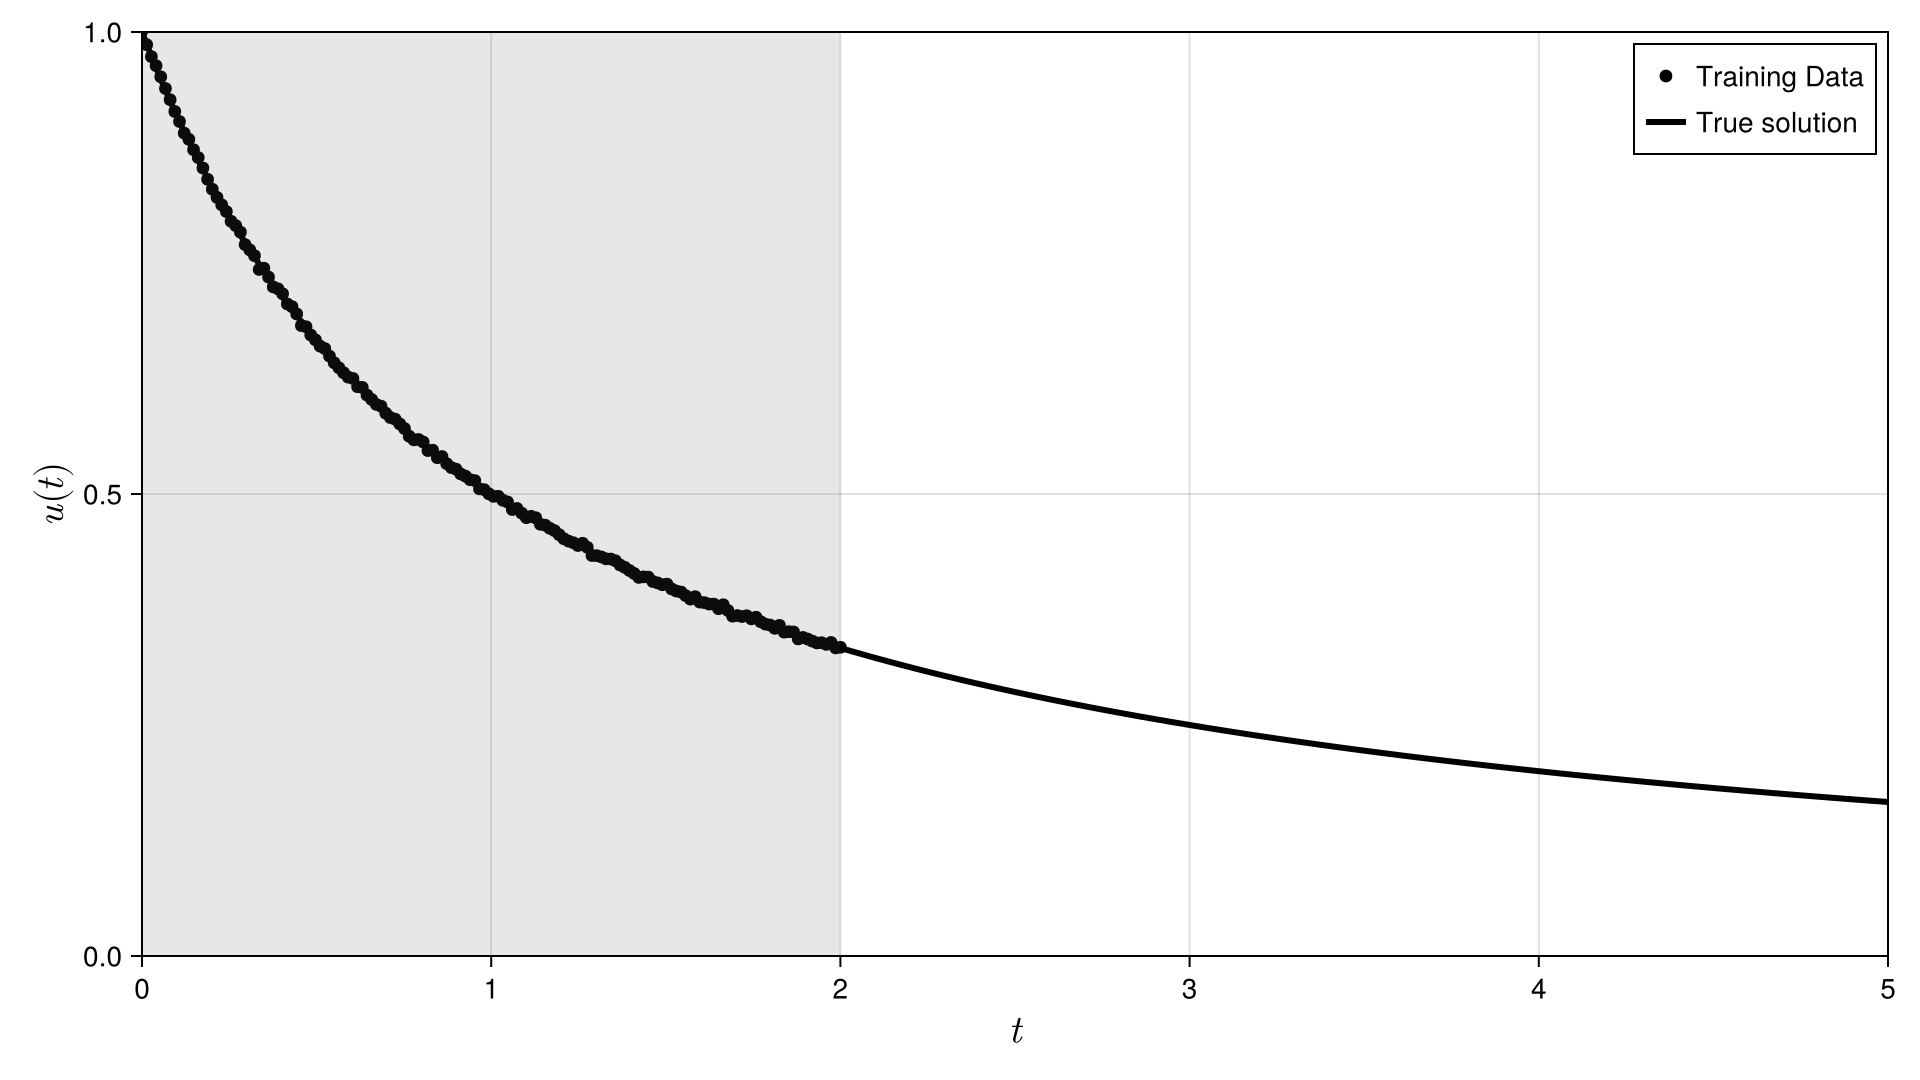

In [16]:
fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)",title="")
CairoMakie.scatter!(ax,tsteps, data[:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[:]; linewidth = 3,color=:black,label="True solution")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.1))
axislegend(ax;position=:rt)
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
fig

Set up architecture of Neural Network

In [17]:
dudtNODEs = Chain(Dense(1, 3, tanh),
            Dense(3, 3, tanh),
             Dense(3, 1))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-0.08216114; -0.54444456; -2.7860525;;], bias = Float32[-0.5999714, 0.72428167, -0.4585489]), layer_2 = (weight = Float32[-0.6418321 -1.2789088 -0.2807452; 0.5387089 1.2171224 0.67334807; -0.54372525 -1.3020481 0.47613382], bias = Float32[-0.14210694, -0.5443836, -0.20890224]), layer_3 = (weight = Float32[0.9969245 0.7939795 0.45440757], bias = Float32[-0.3961207])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Plot initial prediction

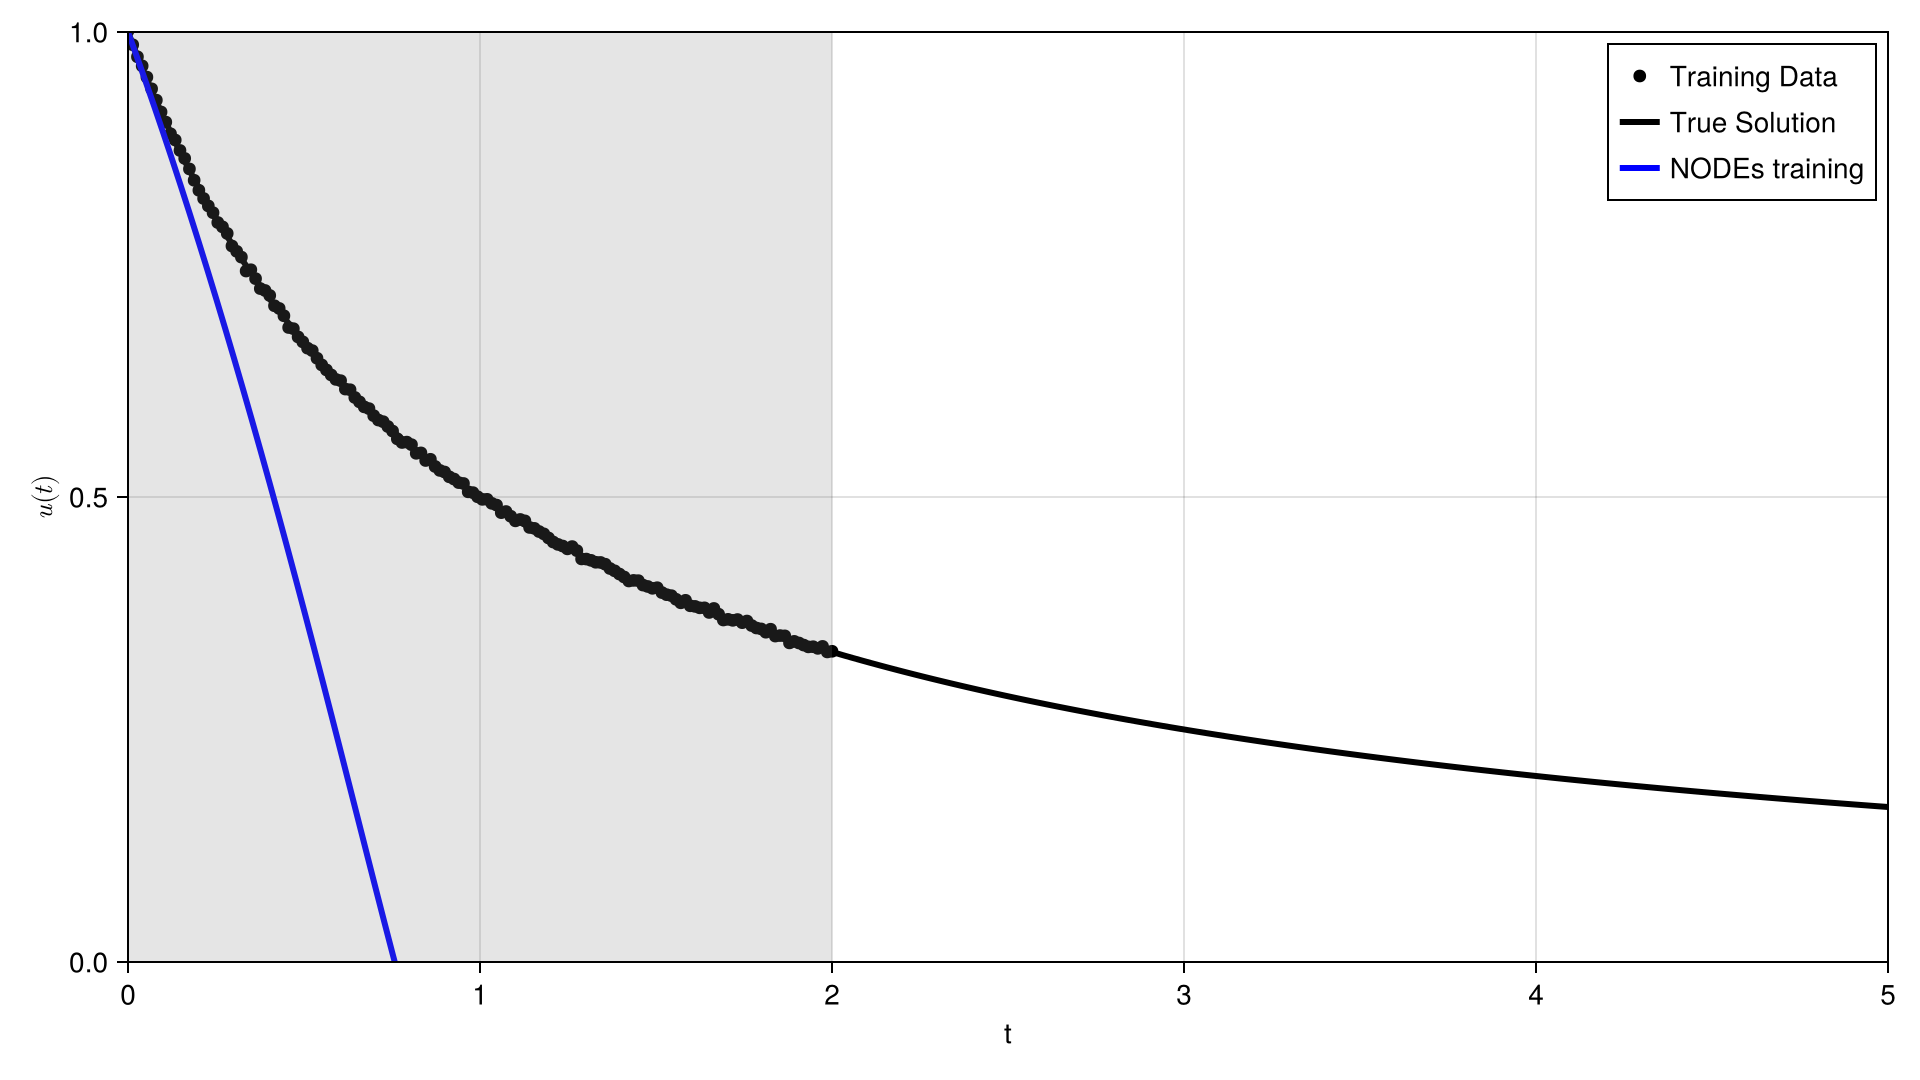

In [18]:
model=StatefulLuxLayer(dudtNODEs, pinit, st)
dudt(u, p, tplot) = model(u, p)
prob = ODEProblem(dudt, u0, (tspan2[1],tspan2[2]), pinit) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)


ComputedSolution_nodes=convert(AbstractArray,nn_sol)

fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],xlabel="t",ylabel=L"u(t)")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax,nn_sol.t,ComputedSolution_nodes[1,:]; linewidth = 3,color=:blue,linestyle=:solid,label="NODEs training")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
fig

Training the model using the adjoint method. 

In [19]:
smodel = StatefulLuxLayer(dudtNODEs, pinit, st)

callback = function (p, l)
    if p.iter % 1000 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

function loss_adjoint(p, (u, t))
    u0 = u[:, 1]
    dudt(u, θ, t) = smodel(u, θ)
    prob = ODEProblem(dudt, u0, (t[1], t[end]), p)
    sol = solve(prob, Tsit5();  saveat=t, sensealg=ReverseDiffAdjoint())
    pred = stack(sol.u)

    return MSELoss()(pred, u)
end

loss_history = Float64[]
opt_func = OptimizationFunction(loss_adjoint, Optimization.AutoZygote())
opt_prob = OptimizationProblem(opt_func, ComponentArray(pinit), (data,tsteps))
numerical_neuralode = Optimization.solve(opt_prob, Optimisers.Adam(learning_rate); callback, epochs = max_iter_NODEs)
loss_history_NODEs=copy(loss_history)


Iteration: 1000, Loss: 0.00010690791242695582
Iteration: 2000, Loss: 7.179916354523106e-5
Iteration: 3000, Loss: 4.226946598867817e-5
Iteration: 4000, Loss: 2.090807977003995e-5
Iteration: 5000, Loss: 8.631067809594027e-6
Iteration: 6000, Loss: 4.609964613889911e-6
Iteration: 7000, Loss: 4.191579776194966e-6
Iteration: 8000, Loss: 4.1679725286484715e-6
Iteration: 9000, Loss: 4.150321182820582e-6
Iteration: 10000, Loss: 4.1194308625328915e-6
Iteration: 10000, Loss: 4.1194308625328915e-6


10001-element Vector{Float64}:
 0.8231758481072337
 0.7065199671148443
 0.5945665239008422
 0.4880320342821766
 0.3877829008772362
 0.2948339031650423
 0.21048592770075608
 0.13672681386633792
 0.07690228038713398
 0.036441565417286166
 ⋮
 4.1195217035774196e-6
 4.119511813632267e-6
 4.1194960629037075e-6
 4.119483885137909e-6
 4.119473875890806e-6
 4.1194588005984616e-6
 4.119445987121611e-6
 4.1194308625328915e-6
 4.1194308625328915e-6

Predict using NODEs solution and plot

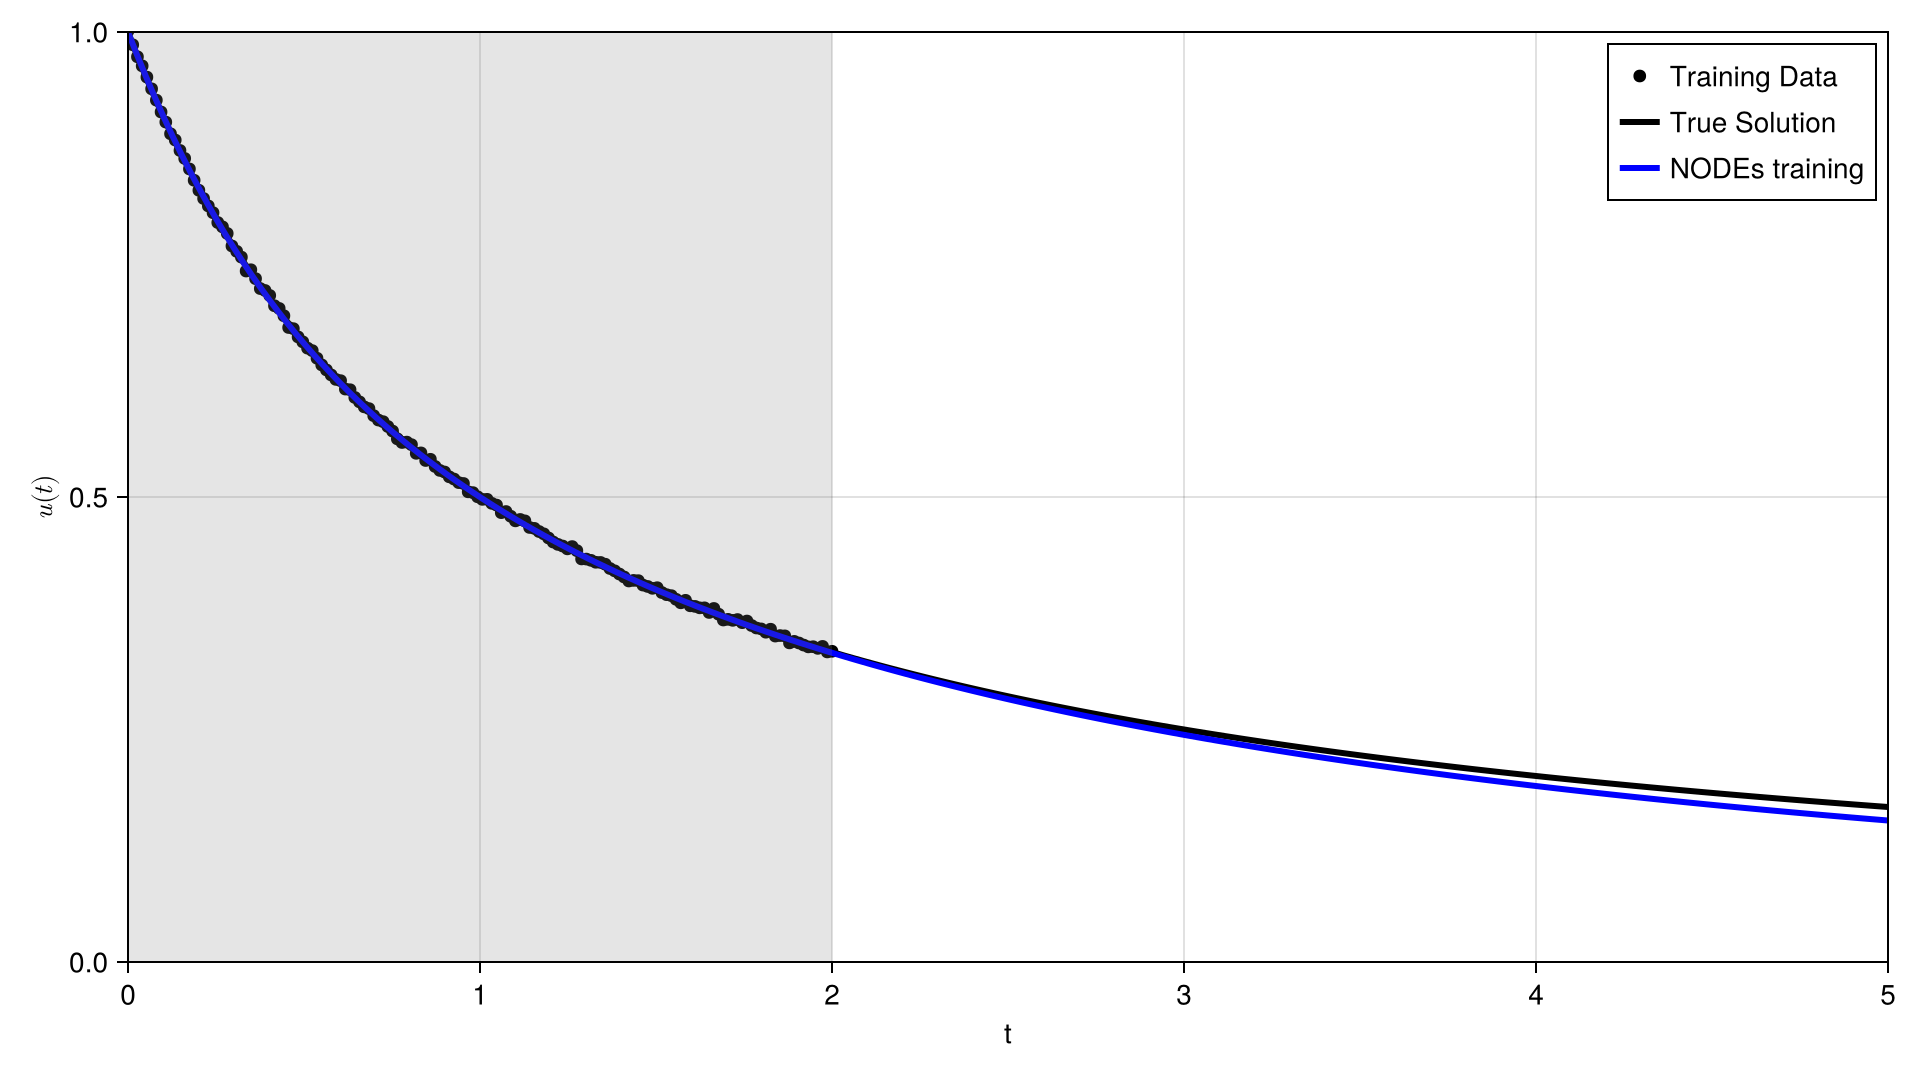

In [20]:
prob = ODEProblem(dudt, u0, (tspan2[1],tspan2[2]), numerical_neuralode.u) 
nn_sol = solve(prob, Tsit5(); saveat=tsteps2)

ComputedSolution_nodes=convert(AbstractArray,nn_sol)

fig = CairoMakie.Figure(size = (960, 540),backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],xlabel="t",ylabel=L"u(t)")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:black,label="Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax,nn_sol.t,ComputedSolution_nodes[1,:]; linewidth = 3,color=:blue,linestyle=:solid,label="NODEs training")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:grey, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
#save("figures/03NODEs_training.png", fig)
fig

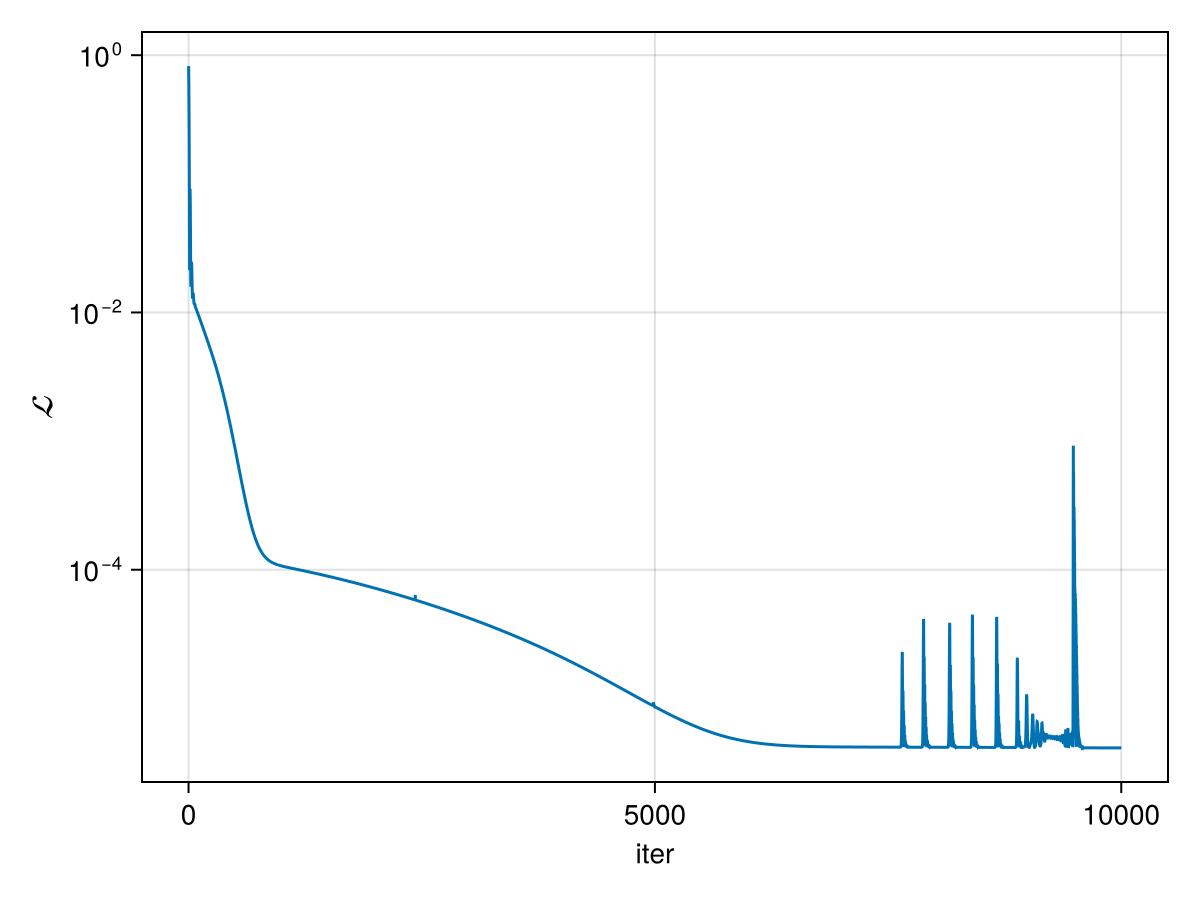

In [21]:
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history_NODEs)
fig

---
**Workshop Demo 01:**   Try changing the training time to $t\in [0,1]$.  What happens to the prediction solution for $t\in[1,5]$?  

---

---
**Workshop Demo 02:**   Rerun this example by setting the noise=0.01.  

---